UPscaledEV Project Main Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Readme:
This code aims at modifying the LMP file name missing problem due to daylight saving, and changing the file name with real date (original was 1 day lag).
In 2025 it's 3/9 and 11/2.

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.

In [1]:
# Set working path and import packages
import os
os.chdir('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/LMP/2025') 
print("Path is:", os.getcwd(), "\n")
import time
from datetime import datetime
import pandas as pd
from pathlib import Path 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import glob

Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/LMP/2025 



In [2]:
dirs = ["DA", "RT", "FM"]
real_days = []

for d in dirs:
    for filename in glob.glob(os.path.join(d, "*.csv")):
        # Read CSV
        # some cases cannot read csv
        try:
            df = pd.read_csv(filename)
            df['INTERVALSTARTTIME_GMT'] = pd.to_datetime(df['INTERVALSTARTTIME_GMT'])
            df = df.sort_values('INTERVALSTARTTIME_GMT').reset_index(drop=True)
        except Exception as e:
            # print(f"Error reading {filename}: {e}") # NOTE: not downloaded yet
            continue

        # Extract actual day from first timestamp
        real_day = df['INTERVALSTARTTIME_GMT'].iloc[0].strftime('%Y%m%d')

        # Build new filename
        new_filename = os.path.join(d, f"{real_day}_LMP.csv")

        # Rename (overwrite if exists)
        os.rename(filename, new_filename)
        
        real_days.append(real_day)
        
# check if real_days covers all days in 2025
all_days_2025 = pd.date_range(start='2025-01-01', end='2025-07-31').strftime('%Y%m%d').tolist()
missing_days = set(all_days_2025) - set(real_days)
if missing_days:
    print("Missing days:", sorted(missing_days))
else:
    print("All days in 2025 are covered.")

All days in 2025 are covered.


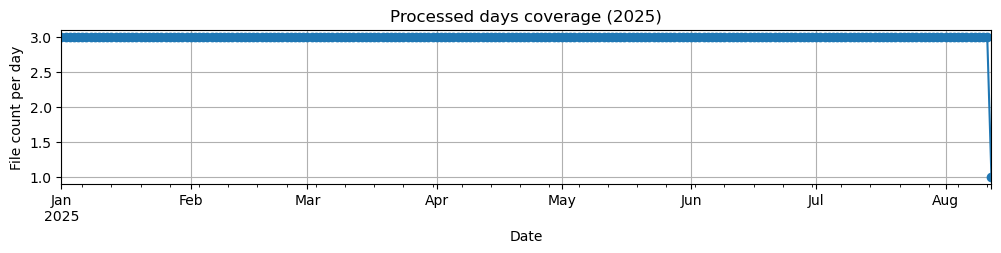

In [3]:
real_days = sorted([int(day) for day in real_days])

# Convert list of ints -> datetime
real_days_dt = pd.to_datetime([str(day) for day in real_days], format="%Y%m%d")

# Make a DataFrame so we can check duplicates
df_days = pd.DataFrame({"day": real_days_dt})

# Count how many times each day appears
counts = df_days["day"].value_counts().sort_index()

# Plot
plt.figure(figsize=(12,2))
counts.plot(marker="o")
plt.title("Processed days coverage (2025)")
plt.ylabel("File count per day")
plt.xlabel("Date")
plt.grid(True)
plt.show()
